Import required libraries and Load dataset

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [23]:
zoo = pd.read_csv("C:\\Users\\kings\\Downloads\\zoo.csv")
classs = pd.read_csv("C:\\Users\\kings\\Downloads\\class.csv")

print(classs)
zoo

   Class_Number  Number_Of_Animal_Species_In_Class    Class_Type  \
0             1                                 41        Mammal   
1             2                                 20          Bird   
2             3                                  5       Reptile   
3             4                                 13          Fish   
4             5                                  4     Amphibian   
5             6                                  8           Bug   
6             7                                 10  Invertebrate   

                                        Animal_Names  
0  aardvark, antelope, bear, boar, buffalo, calf,...  
1  chicken, crow, dove, duck, flamingo, gull, haw...  
2    pitviper, seasnake, slowworm, tortoise, tuatara  
3  bass, carp, catfish, chub, dogfish, haddock, h...  
4                             frog, frog, newt, toad  
5  flea, gnat, honeybee, housefly, ladybird, moth...  
6  clam, crab, crayfish, lobster, octopus, scorpi...  


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [24]:
##Map class number to readable names
classs.columns
class_map = dict(zip(classs["Class_Number"], classs["Class_Type"]))
zoo["class_name"] = zoo["class_type"].map(class_map)
zoo.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type,class_name
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,Mammal
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,Mammal
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4,Fish
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,Mammal
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,Mammal


In [25]:
##Data Quality Check
print("=== Data Type ===")
print(zoo.dtypes)

print(" ")
print("=== Missing Value ===")
print(zoo.isna())
zoo.isna().sum()


=== Data Type ===
animal_name    object
hair            int64
feathers        int64
eggs            int64
milk            int64
airborne        int64
aquatic         int64
predator        int64
toothed         int64
backbone        int64
breathes        int64
venomous        int64
fins            int64
legs            int64
tail            int64
domestic        int64
catsize         int64
class_type      int64
class_name     object
dtype: object
 
=== Missing Value ===
     animal_name   hair  feathers   eggs   milk  airborne  aquatic  predator  \
0          False  False     False  False  False     False    False     False   
1          False  False     False  False  False     False    False     False   
2          False  False     False  False  False     False    False     False   
3          False  False     False  False  False     False    False     False   
4          False  False     False  False  False     False    False     False   
..           ...    ...       ...    ...    ..

animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
class_type     0
class_name     0
dtype: int64

Exploratory Data Analysis

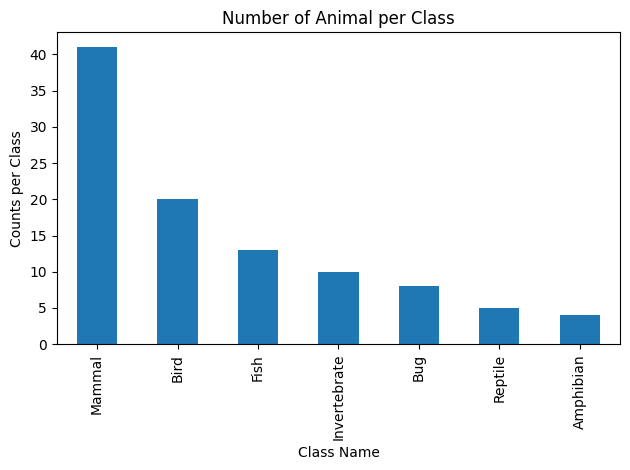

In [26]:
##How many animals are in each class?
#count animal per class
counts = zoo["class_name"].value_counts()

#count plot
counts.plot(kind = "bar")
plt.title("Number of Animal per Class")
plt.xlabel("Class Name")
plt.ylabel("Counts per Class")
plt.tight_layout()
plt.show()

In [27]:
zoo.columns

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type',
       'class_name'],
      dtype='object')

In [28]:
##What does each features look like per class?
features = ["hair", "feathers", "eggs", "milk", "airborne",
       "aquatic", "predator", "toothed", "backbone", "breathes", "venomous",
       "fins", "legs", "tail", "domestic", "catsize"]

print(features)

feature_mean = zoo.groupby("class_name")[features].mean()
print(feature_mean)

['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']
                 hair  feathers     eggs  milk  airborne   aquatic  predator  \
class_name                                                                     
Amphibian     0.00000       0.0  1.00000   0.0   0.00000  1.000000  0.750000   
Bird          0.00000       1.0  1.00000   0.0   0.80000  0.300000  0.450000   
Bug           0.50000       0.0  1.00000   0.0   0.75000  0.000000  0.125000   
Fish          0.00000       0.0  1.00000   0.0   0.00000  1.000000  0.692308   
Invertebrate  0.00000       0.0  0.90000   0.0   0.00000  0.600000  0.800000   
Mammal        0.95122       0.0  0.02439   1.0   0.04878  0.146341  0.536585   
Reptile       0.00000       0.0  0.80000   0.0   0.00000  0.200000  0.800000   

              toothed  backbone  breathes  venomous      fins      legs  \
class_name                            

In [29]:
## Do any features move together?
cor = zoo[features].corr()
print(cor["backbone"].sort_values(ascending = False))
print(cor)

backbone    1.000000
tail        0.731762
toothed     0.575085
milk        0.384958
catsize     0.356976
feathers    0.231403
fins        0.209499
breathes    0.207666
hair        0.191681
domestic    0.101733
predator    0.051022
aquatic     0.022463
airborne   -0.104718
venomous   -0.246611
eggs       -0.340420
legs       -0.432856
Name: backbone, dtype: float64
              hair  feathers      eggs      milk  airborne   aquatic  \
hair      1.000000 -0.427851 -0.817382  0.878503 -0.198431 -0.473554   
feathers -0.427851  1.000000  0.419248 -0.410761  0.656553 -0.058552   
eggs     -0.817382  0.419248  1.000000 -0.938848  0.376646  0.376244   
milk      0.878503 -0.410761 -0.938848  1.000000 -0.366765 -0.362613   
airborne -0.198431  0.656553  0.376646 -0.366765  1.000000 -0.172638   
aquatic  -0.473554 -0.058552  0.376244 -0.362613 -0.172638  1.000000   
predator -0.154769 -0.104430  0.011605 -0.029721 -0.295181  0.375978   
toothed   0.492531 -0.613631 -0.642150  0.628168 -0.59431

Data Pre-processing and Feature Engineering


In [30]:
##Drop less useful columns
x = zoo.drop(columns = ["animal_name", "class_type", "class_name"])
y = zoo["class_name"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(x.columns))

Features shape: (101, 16)
Target shape: (101,)

Feature columns: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']


Train - Test Split

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 123, stratify = y)

Model Training

In [32]:
## Decision Tree Clasifier
tree_model = DecisionTreeClassifier(max_depth = 4, class_weight = "balanced", random_state = 123)
tree_model.fit(x_train, y_train)

print("Training Accuracy:", tree_model.score(x_train, y_train))
print("Test Accuracy:", tree_model.score(x_test, y_test))

Training Accuracy: 0.8625
Test Accuracy: 0.7619047619047619


In [33]:
## Random forest
forest_model = RandomForestClassifier(n_estimators = 200,  #number of trees
                                      class_weight = "balanced",
                                      random_state = 123)

forest_model.fit(x_train, y_train)

print("Train Accuracy:", forest_model.score(x_train, y_train))
print("Test Accuracy:", forest_model.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.8571428571428571


In [37]:
## Gradient Boosting
boost_model = GradientBoostingClassifier(n_estimators = 100, #no of trees
                                         learning_rate = 0.1,
                                         max_depth = 3, random_state = 123)

boost_model.fit(x_train, y_train)

print("Train Accuracy:", boost_model.score(x_train, y_train))
print("Test Accuracy:", boost_model.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9047619047619048


Model Evaluation

In [52]:
## Classification Report
#Get predictions from each model
t_pred = tree_model.predict(x_test)
r_pred = forest_model.predict(x_test)
gb_pred = boost_model.predict(x_test)

print("Decision Tree:", classification_report(y_test, r_pred, target_names=list(class_map.values())))
print("\nRandom Forest:", classification_report(y_test, r_pred, target_names=list(class_map.values())))
print("\nGradient Boosting:", classification_report(y_test, gb_pred, target_names=list(class_map.values())))

Decision Tree:               precision    recall  f1-score   support

      Mammal       0.00      0.00      0.00         1
        Bird       1.00      1.00      1.00         4
     Reptile       0.67      1.00      0.80         2
        Fish       0.75      1.00      0.86         3
   Amphibian       1.00      0.50      0.67         2
         Bug       1.00      1.00      1.00         8
Invertebrate       0.00      0.00      0.00         1

    accuracy                           0.86        21
   macro avg       0.63      0.64      0.62        21
weighted avg       0.84      0.86      0.83        21


Random Forest:               precision    recall  f1-score   support

      Mammal       0.00      0.00      0.00         1
        Bird       1.00      1.00      1.00         4
     Reptile       0.67      1.00      0.80         2
        Fish       0.75      1.00      0.86         3
   Amphibian       1.00      0.50      0.67         2
         Bug       1.00      1.00      1.00    

C:\Users\kings\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kings\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kings\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

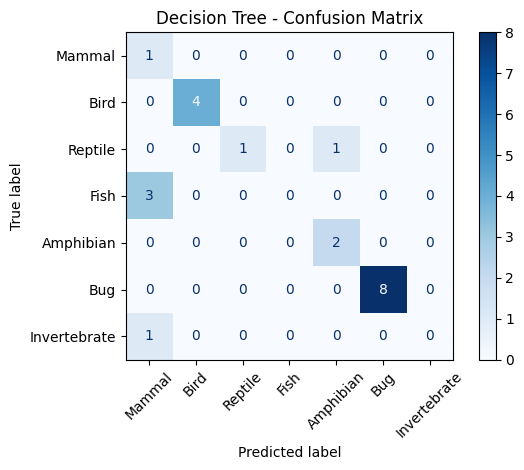

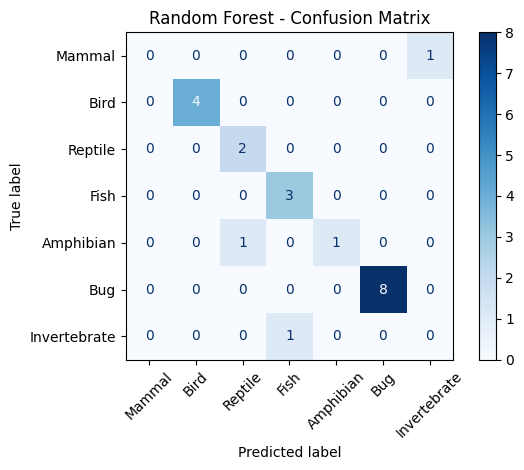

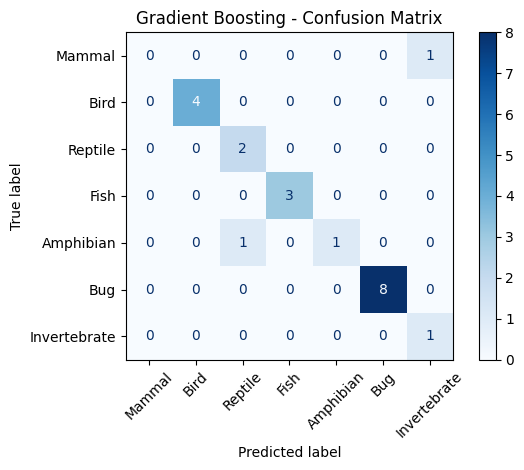

In [54]:
## Confusion Matrix
cm = confusion_matrix(y_test, t_pred, labels = sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = list(class_map.values()))
disp.plot(cmap = "Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

c_m = confusion_matrix(y_test, r_pred, labels = sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix = c_m, display_labels = list(class_map.values()))
disp.plot(cmap = "Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

cm_ = confusion_matrix(y_test, gb_pred, labels = sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix = cm_, display_labels = list(class_map.values()))
disp.plot(cmap = "Blues")
plt.title("Gradient Boosting - Confusion Matrix")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

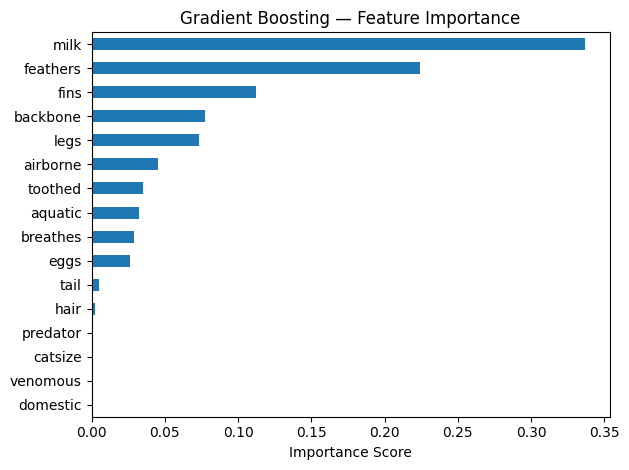

Top 5 features:
milk        0.336617
feathers    0.224077
fins        0.112048
backbone    0.077149
legs        0.073043
dtype: float64


In [62]:
## Feature Importance
importance = pd.Series(boost_model.feature_importances_, index = x.columns)
importance = importance.sort_values(ascending = True)

importance.plot(kind = "barh")
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Print the top 5
print("Top 5 features:")
print(importance.sort_values(ascending=False).head(5))